# PulseLM Biosignal Pipeline (Colab version)

**Dataset:** [`Manhph2211/PulseLM`](https://huggingface.co/datasets/Manhph2211/PulseLM)

## Index

- [0: Environment setup](#0-environment-setup)
- [1: Feature extractor](#1-feature-extractor)
  - [1.1: QA label parser](#11-qa-label-parser)
  - [1.2: Diagnostic - preview the QA format](#12-diagnostic---preview-the-qa-format)
- [2: Streaming ingestion → parquet files with labels](#2-streaming-ingestion--parquet-files-with-labels)
- [3: Load features back from disk (lazy, low-memory)](#3-load-features-back-from-disk-lazy-low-memory)
- [4: Load parquet with Spark for distributed processing](#4-load-parquet-with-spark-for-distributed-processing)
  - [4.1: Data cleaning: schema check, null/NaN filter, SQI gate](#41-data-cleaning-schema-check-nullnan-filter-sqi-gate)
  - [4.2: Feature importance - F-ratio ranking and box-plots](#42-feature-importance---f-ratio-ranking-and-box-plots)
  - [4.3: Label coverage and class distribution](#43-label-coverage-and-class-distribution)
  - [4.4: Example signals from each dataset](#44-example-signals-from-each-dataset)
- [5: Machine learning pipeline](#5-machine-learning-pipeline)
  - [5.1: Prepare binary target columns](#51-prepare-binary-target-columns)
  - [5.1b: Inverse-frequency class weights](#51b-inverse-frequency-class-weights)
  - [5.2: Spark Random Forest - subset training](#52-spark-random-forest---subset-training)
  - [5.3: Spark Random Forest - whole-dataset training with weights](#53-spark-random-forest---whole-dataset-training-with-weights)
  - [5.4: Spark MLP - multi-layer perceptron per task](#54-spark-mlp---multi-layer-perceptron-per-task)
  - [5.5: PyTorch multi-task NN (bonus baseline)](#55-pytorch-multi-task-nn-bonus-baseline)
  - [5.6: Model comparison and baseline](#56-model-comparison-and-baseline)
  - [5.7: Run clinical predictions on test signals](#57-run-clinical-predictions-on-test-signals)

## 0: Environment setup

This section installs the libraries and sets the basic paths. When running this in Colab, this is also where you decide whether to mount Google Drive so your outputs survive after the session ends.

In [7]:
!pip install -q huggingface_hub datasets pyarrow scikit-learn matplotlib seaborn tqdm scipy

In [8]:
from huggingface_hub import login
login()

In [9]:
import os

# HuggingFace token (get yours from https://huggingface.co/settings/tokens)
HF_TOKEN = ""  # ← your token here, e.g. "hf_xxxxxxxxxxxx"

# Output directory for parquet files.
# Use a local path for a single session, or a Drive path to persist across sessions:
#   OUT_DIR = "/content/drive/MyDrive/pulse_features"  # requires Drive mount below
OUT_DIR = "/content/pulse_features"

# Mount Google Drive so parquet survives across sessions.
MOUNT_DRIVE = False  # set True to mount
if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUT_DIR = "/content/drive/MyDrive/pulse_features"

os.makedirs(f"{OUT_DIR}/train",      exist_ok=True)
os.makedirs(f"{OUT_DIR}/validation", exist_ok=True)
os.makedirs(f"{OUT_DIR}/test",       exist_ok=True)

print(f"OUT_DIR : {OUT_DIR}")
print(f"HF_TOKEN: {'set' if HF_TOKEN else 'NOT SET - fill token'}")


OUT_DIR : /content/pulse_features
HF_TOKEN: NOT SET - fill token


## 1: Feature extractor

Here we turn each raw signal into a small set of summary numbers. The goal is not to keep every sample, but to capture the parts that are most useful for quick modeling and comparison.

In [10]:
import numpy as np

FEATURE_NAMES = [
    "mean", "std", "min", "max", "p2p",
    "skew", "kurt", "zcr", "dom_freq",
]

def extract_features(signal):
    """Extract 9 summary features from a 1-D signal array."""
    if signal is None or len(signal) == 0:
        return [0.0] * len(FEATURE_NAMES)
    x = np.asarray(signal, dtype=np.float32)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return [0.0] * len(FEATURE_NAMES)

    mean = float(x.mean()); std = float(x.std())
    centered = x - mean
    skew = float(((centered ** 3).mean() / (std ** 3 + 1e-12)))
    kurt = float(((centered ** 4).mean() / (std ** 4 + 1e-12)) - 3.0)
    zcr  = float(np.mean(np.diff(np.signbit(centered)).astype(float)))

    spec = np.abs(np.fft.rfft(centered))
    dom  = float(np.argmax(spec[1:]) + 1) if spec.size > 1 else 0.0

    return [mean, std, float(x.min()), float(x.max()),
            float(x.max() - x.min()), skew, kurt, zcr, dom]

feature_cols = [f"f_{name}" for name in FEATURE_NAMES]
print(f"feature_cols defined: {feature_cols}")


feature_cols defined: ['f_mean', 'f_std', 'f_min', 'f_max', 'f_p2p', 'f_skew', 'f_kurt', 'f_zcr', 'f_dom_freq']


## 1.1: QA label parser

The dataset stores the labels in a QA field, but not always in the same shape. This parser cleans that up, matches each question to the right task, and returns a consistent label name that the rest of the notebook can use.

It also checks answers against the allowed label set so we do not accidentally carry forward malformed text.

In [11]:
import json, ast

# 12 PulseLM task buckets
LABEL_TASKS = [
    "HR", "BP", "SQI", "Stress", "SDB",
    "HRV_SDNN", "HRV_RMSSD", "HRV_pNN50",
    "AF", "Arrhythmia", "SpO2", "RR",
]

# Closed-vocabulary answer sets per task
ANSWER_SETS = {
    "HR":         {"bradycardia", "normal", "tachycardia"},
    "BP":         {"normal", "elevated", "hypertension_stage1", "hypertension_stage2", "hypertensive_crisis"},
    "SQI":        {"good", "noisy"},
    "Stress":     {"baseline", "stress", "amusement", "meditation"},
    "SDB":        {"normal_ahi<5", "mild_5<=ahi<15", "moderate_15<=ahi<30", "severe_ahi>=30"},
    "HRV_SDNN":   {"low", "normal", "high"},
    "HRV_RMSSD":  {"low", "normal", "high"},
    "HRV_pNN50":  {"low", "normal", "high"},
    "AF":         {"af", "non_af"},
    "Arrhythmia": {"sinus_rhythm", "pvc", "pac", "vt", "svt", "af"},
    "SpO2":       {"normal", "abnormal"},
    "RR":         {"bradypnea", "normal", "tachypnea"},
}

# Map QA field keys to task names
TASK_KEY_MAP = {
    "heart_rate_category":    "HR",
    "hr_category":            "HR",
    "blood_pressure_category":"BP",
    "bp_category":            "BP",
    "sqi_category":           "SQI",
    "signal_quality_category":"SQI",
    "stress_label":           "Stress",
    "stress_category":        "Stress",
    "sdb_label":              "SDB",
    "sdb_category":           "SDB",
    "hrv_sdnn_category":      "HRV_SDNN",
    "sdnn_category":          "HRV_SDNN",
    "hrv_rmssd_category":     "HRV_RMSSD",
    "rmssd_category":         "HRV_RMSSD",
    "hrv_pnn50_category":     "HRV_pNN50",
    "pnn50_category":         "HRV_pNN50",
    "af_label":               "AF",
    "af_category":            "AF",
    "arrhythmia_category":    "Arrhythmia",
    "arrhythmia_label":       "Arrhythmia",
    "spo2_category":          "SpO2",
    "rr_category":            "RR",
    "respiratory_rate_category":"RR",
}

# Keyword matching on question text
ROUTER_KEYWORDS = [
    ("HRV_SDNN",   ["sdnn"]),
    ("HRV_RMSSD",  ["rmssd", "parasympathetic"]),
    ("HRV_pNN50",  ["pnn50"]),
    ("AF",         ["atrial fibrillation", "af detection", "af label", "af or non-af",
                    "indicate af", "af present", " af?", " af "]),
    ("Arrhythmia", ["arrhythmia", "cardiac rhythm", "type of arrhythmia",
                    "rhythm classification", "rhythm diagnosis",
                    "heart rhythm abnormality", "rhythm category"]),
    ("SDB",        ["sleep-disordered", "sleep disordered", "sleep apnea",
                    "apnea", "ahi", "sdb", "respiratory disturbance",
                    "sleep breathing", "breathing disorder"]),
    ("Stress",     ["stress", "emotional state", "affective state",
                    "psychological state", "stress condition", "stress state"]),
    ("SQI",        ["signal quality", "sqi", "clean or motion distorted",
                    "good or poor quality", "quality of this ppg",
                    "quality category"]),
    ("BP",         ["blood pressure", "hypertension", "bp class",
                    "bp classification", "bp category"]),
    ("SpO2",       ["spo2", "oxygen saturation", "hypoxemia", "blood oxygen"]),
    ("RR",         ["respiratory rate", "breathing rate", "respiration rate"]),
    ("HR",         ["heart rate", "hr category", "bradycardic", "tachycardic",
                    "pulse rate", "bpm"]),
]


def _norm_answer(s):
    """Normalize answer strings: lowercase, underscores."""
    return str(s).strip().lower().replace(" ", "_").replace("-", "_")


def _decode_qa(qa_field):
    """Decode QA field from string or return as-is."""
    if qa_field is None:
        return None
    if isinstance(qa_field, str):
        s = qa_field.strip()
        if not s:
            return None
        try:
            return json.loads(s)
        except json.JSONDecodeError:
            try:
                return ast.literal_eval(s)
            except Exception:
                return None
    return qa_field


def _route_by_question(question, answer, validate=True):
    """Match question text against keywords to assign a task."""
    a = _norm_answer(answer)
    ql = (question or "").lower()
    for task, kws in ROUTER_KEYWORDS:
        if any(kw in ql for kw in kws):
            if validate and (task in ANSWER_SETS) and (a not in ANSWER_SETS[task]):
                continue
            return (task, a)
    return None


def parse_qa_labels(qa_field, validate=True):
    """Parse QA pairs into {task_name: answer} dict."""
    qa = _decode_qa(qa_field)
    if qa is None:
        return {}

    out = {}

    # Task-keyed dict with {"question":..., "answer":...} values
    if isinstance(qa, dict):
        looks_like_pulselm = any(
            isinstance(v, dict) and ("answer" in v or "a" in v) for v in qa.values()
        )
        if looks_like_pulselm:
            for key, val in qa.items():
                if not isinstance(val, dict):
                    continue
                task = TASK_KEY_MAP.get(str(key).lower())
                ans  = val.get("answer") or val.get("a")
                if ans is None:
                    continue
                a = _norm_answer(ans)
                if task is None:
                    q = val.get("question") or val.get("q") or ""
                    r = _route_by_question(q, ans, validate)
                    if r is not None:
                        out[r[0]] = r[1]
                    continue
                if validate and (task in ANSWER_SETS) and (a not in ANSWER_SETS[task]):
                    continue
                out[task] = a
            return out

        # Parallel lists: {"question":[...], "answer":[...]}
        qs  = qa.get("question") or qa.get("questions") or qa.get("q")
        as_ = qa.get("answer")   or qa.get("answers")   or qa.get("a")
        if qs is not None and as_ is not None:
            if isinstance(qs, str) and isinstance(as_, str):
                pairs = [(qs, as_)]
            else:
                pairs = list(zip(qs, as_))
            for q, a in pairs:
                r = _route_by_question(str(q), a, validate)
                if r is not None:
                    out[r[0]] = r[1]
        return out

    # Fallback: List of dicts or list of pairs
    if isinstance(qa, (list, tuple)):
        for item in qa:
            if isinstance(item, dict):
                q = item.get("question") or item.get("q") or ""
                a = item.get("answer")   or item.get("a") or ""
            elif isinstance(item, (list, tuple)) and len(item) >= 2:
                q, a = item[0], item[1]
            else:
                continue
            r = _route_by_question(str(q), a, validate)
            if r is not None:
                out[r[0]] = r[1]
        return out

    return out


# Test
_TESTS = [
    '{"af_label": {"question": "Is atrial fibrillation present in this recording?", "answer": "non_af"}}',
    '{"heart_rate_category": {"question": "What heart rate classification does this PPG indicate?", "answer": "normal"}, "blood_pressure_category": {"question": "Provide the blood pressure risk category.", "answer": "elevated"}}',
    '[{"question": "Does this PPG signal show atrial fibrillation?", "answer": "af"}, {"question": "What is the heart rate category for this PPG segment?", "answer": "normal"}]',
    '{"weird_arrhythmia_thing": {"question": "What is the arrhythmia category for this segment?", "answer": "pvc"}}',
]
print("Test:")
for t in _TESTS:
    print(" ", parse_qa_labels(t))


Test:
  {'AF': 'non_af'}
  {'HR': 'normal', 'BP': 'elevated'}
  {'AF': 'af', 'HR': 'normal'}
  {'Arrhythmia': 'pvc'}


## 1.2: Diagnostic - preview the QA format

Before processing the full dataset, this quick check shows what the QA field looks like in each config and how the parser handles it. It is a simple sanity check that helps catch parsing mistakes early.

In [12]:
from datasets import load_dataset, get_dataset_config_names
import json as _json

DATASET_ID = "Manhph2211/PulseLM"
_cfgs = get_dataset_config_names(DATASET_ID)

print(f"{'config':<14} {'qa keys':<28} {'parsed labels'}")
print("-" * 96)
for _cfg in _cfgs:
    try:
        _row = next(iter(load_dataset(DATASET_ID, _cfg, split="train", streaming=True)))
    except Exception as _e:
        print(f"{_cfg:<14} ERROR: {type(_e).__name__}: {str(_e)[:60]}")
        continue
    _qa  = _row.get("qa")
    # Describe the structure compactly, then probe one parsed pair
    if isinstance(_qa, str):
        _shape = f"str({len(_qa)})"
        _example_str = _qa[:160].replace("\n", " ")
    elif isinstance(_qa, list) and _qa and isinstance(_qa[0], dict):
        _shape = f"list[{len(_qa)}] of dict {list(_qa[0].keys())}"
        _example_str = None
    elif isinstance(_qa, dict):
        _shape = f"dict {list(_qa.keys())}"
        _example_str = None
    else:
        _shape = type(_qa).__name__
        _example_str = None

    _labels = parse_qa_labels(_qa)
    print(f"{_cfg:<14} {_shape[:28]:<28} {_labels}")
    if _example_str is not None:
        print(f"{'':<14}   raw qa head: {_example_str}")


config         qa keys                      parsed labels
------------------------------------------------------------------------------------------------
afppgecg       str(99)                      {'AF': 'non_af'}
                 raw qa head: {"af_label": {"question": "Is atrial fibrillation present in this recording?", "answer": "non_af"}}
bcg            str(341)                     {'HR': 'normal', 'BP': 'normal'}
                 raw qa head: {"heart_rate_category": {"question": "What heart rate classification does this PPG indicate?", "answer": "normal"}, "blood_pressure_category": {"question": "Wha
bidmc          str(205)                     {'RR': 'tachypnea', 'SpO2': 'normal'}
                 raw qa head: {"rr_category": {"question": "How would you categorize the respiratory rate here?", "answer": "tachypnea"}, "spo2_category": {"question": "What is the SpO2 cate
dalia          str(214)                     {'HR': 'normal'}
                 raw qa head: {"heart_rate_category"

## 2: Streaming ingestion → parquet files with labels

This is where the notebook does the heavy lifting. It streams each dataset split from Hugging Face, extracts the signal features, pulls out the labels, and writes everything to parquet in batches so the process stays manageable.

In [13]:
import os, time, json, pickle
from datasets import load_dataset, get_dataset_config_names
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq

DATASET_ID         = "Manhph2211/PulseLM"
SAMPLES_PER_SPLIT  = None         # None = all rows
BATCH_SIZE         = 500          # rows before flushing to disk
SKIP_EXISTING      = False        # skip configs with existing parquet
CONFIGS_TO_DROP    = ["afppgecg"]  # too large and imbalanced

config_names = [c for c in get_dataset_config_names(DATASET_ID) if c not in CONFIGS_TO_DROP]
if CONFIGS_TO_DROP:
    print(f"Skipping configs: {CONFIGS_TO_DROP}")
print(f"Using {len(config_names)} configs: {', '.join(config_names)}")

os.makedirs(f"{OUT_DIR}/train",      exist_ok=True)
os.makedirs(f"{OUT_DIR}/validation", exist_ok=True)
os.makedirs(f"{OUT_DIR}/test",       exist_ok=True)

preview_signals = {}

def fetch_to_parquet(cfg, split_name, n_target, batch_size):
    """Stream one config/split, extract features and labels, write to parquet."""
    try:
        stream = load_dataset(DATASET_ID, cfg, split=split_name, streaming=True)
    except (ValueError, KeyError):
        return 0

    out_path = f"{OUT_DIR}/{split_name}/{cfg}.parquet"
    if SKIP_EXISTING and os.path.exists(out_path):
        try:
            n_existing = pq.ParquetFile(out_path).metadata.num_rows
        except Exception:
            n_existing = 0
        return n_existing
    writer   = None
    batch    = []
    n_written = 0

    pbar = tqdm(desc=f"{cfg}/{split_name}", total=n_target, unit="row", leave=False)

    def _force_label_cols_string(tbl):
        """Ensure label columns are always string type for schema consistency."""
        new_fields, new_cols = [], []
        for field, col in zip(tbl.schema, tbl.columns):
            if field.name.startswith("lbl_") and not pa.types.is_string(field.type):
                new_fields.append(pa.field(field.name, pa.string()))
                new_cols.append(col.cast(pa.string()))
            else:
                new_fields.append(field)
                new_cols.append(col)
        return pa.Table.from_arrays(new_cols, schema=pa.schema(new_fields))

    def flush():
        nonlocal writer, batch, n_written
        if not batch:
            return
        tbl = pa.Table.from_pylist(batch)
        tbl = _force_label_cols_string(tbl)
        if writer is None:
            writer = pq.ParquetWriter(out_path, tbl.schema, compression="snappy")
        writer.write_table(tbl)
        n_written += len(batch)
        batch.clear()

    try:
        for row in stream:
            if n_target is not None and (n_written + len(batch)) >= n_target:
                break
            signal = row.get("signal")
            if signal is None:
                continue

            if split_name == "train" and cfg not in preview_signals:
                preview_signals[cfg] = list(signal[:1000])

            feats = extract_features(signal)
            rec = {f"f_{name}": feats[i] for i, name in enumerate(FEATURE_NAMES)}
            rec["signal_len"] = len(signal)
            rec["text_len"]   = len(row.get("text") or "")
            rec["qa_count"]   = len(row.get("qa") or [])
            rec["dataset"]    = cfg

            qa_labels = parse_qa_labels(row.get("qa"))
            for task in LABEL_TASKS:
                rec[f"lbl_{task}"] = qa_labels.get(task)

            batch.append(rec)
            pbar.update(1)

            if len(batch) >= batch_size:
                flush()
        flush()
    finally:
        if writer is not None:
            writer.close()
        pbar.close()

    return n_written

tasks = [(cfg, sp) for cfg in config_names for sp in ("train", "validation", "test")]
totals = {"train": 0, "validation": 0, "test": 0}

cap = "unlimited" if SAMPLES_PER_SPLIT is None else f"{SAMPLES_PER_SPLIT:,}/split"
print(f"\nIngesting {len(tasks)} tasks (cap: {cap}, batch: {BATCH_SIZE})...\n")
t_ingest_start = time.time()

for i, (cfg, sp) in enumerate(tasks, 1):
    try:
        n = fetch_to_parquet(cfg, sp, SAMPLES_PER_SPLIT, BATCH_SIZE)
        totals[sp] += n
        status = f"{n:>6,} rows"
    except Exception as e:
        status = f"FAILED ({type(e).__name__}: {str(e)[:60]})"
    elapsed = time.time() - t_ingest_start
    print(f"  [{i:2d}/{len(tasks)}]  {cfg:<14} {sp:<11} {status}   ({elapsed:6.1f}s elapsed)", flush=True)

with open(f"{OUT_DIR}/preview_signals.pkl", "wb") as f:
    pickle.dump(preview_signals, f)

print(f"\nDone. train: {totals['train']:,}  |  validation: {totals['validation']:,}  |  test: {totals['test']:,} rows")
print(f"Parquet folder: {OUT_DIR}/  ({len(preview_signals)} preview signals saved)")


Skipping configs: ['afppgecg']
Using 15 configs: bcg, bidmc, dalia, earset, mimicperform, ppgarrhythmia, ppgbp, sdb, sensors, uci, uqvitalsigns, utsappg, vitaldb, wesad, wildppg

Ingesting 45 tasks (cap: unlimited, batch: 500)...



bcg/train: 0row [00:00, ?row/s]

  [ 1/45]  bcg            train          521 rows   (   3.9s elapsed)


bcg/validation: 0row [00:00, ?row/s]

  [ 2/45]  bcg            validation      86 rows   (   6.2s elapsed)


...

  [43/45]  wildppg        train       180,000 rows   (2166.7s elapsed)


wildppg/validation: 0row [00:00, ?row/s]

  [44/45]  wildppg        validation  15,000 rows   (2219.5s elapsed)


wildppg/test: 0row [00:00, ?row/s]

  [45/45]  wildppg        test        45,000 rows   (2383.5s elapsed)

Done. train: 728,621  |  validation: 82,337  |  test: 128,168 rows
Parquet folder: /content/pulse_features/  (15 preview signals saved)


## 3: Load features back from disk (lazy, low-memory)

Once the parquet files exist, we can read them back in with pandas for lighter analysis. This is the easy path when you want to inspect the features without spinning up Spark again.

In [14]:
import pandas as pd

train_pd = pd.read_parquet(f"{OUT_DIR}/train")
val_pd   = pd.read_parquet(f"{OUT_DIR}/validation")
try:
    test_pd = pd.read_parquet(f"{OUT_DIR}/test")
except (FileNotFoundError, OSError):
    test_pd = pd.DataFrame()
    print("(no test parquet found - set SKIP_EXISTING=True and re-run that cell to fetch only the test split)")

for name, df in [("train", train_pd), ("val", val_pd), ("test", test_pd)]:
    if len(df):
        mb = df.memory_usage(deep=True).sum() / 1e6
        print(f"{name+'_pd':<10} {len(df):>9,} rows  {mb:>6.1f} MB")

label_cols = [c for c in train_pd.columns if c.startswith("lbl_")]
print(f"\nLabel coverage (rows with non-null label per split):")
cov = pd.DataFrame({
    "train":      train_pd[label_cols].notna().sum(),
    "validation": val_pd[label_cols].notna().sum(),
    "test":       test_pd[label_cols].notna().sum() if len(test_pd) else 0,
})
print(cov.to_string())

train_pd.head()

train_pd     728,621 rows   373.8 MB
val_pd        82,337 rows    42.2 MB
test_pd      128,168 rows    65.7 MB

Label coverage (rows with non-null label per split):
                 train  validation   test
lbl_HR          470920       51859  90459
lbl_BP          247816       30742  34549
lbl_SQI              0           0      0
lbl_Stress        2104         297    597
lbl_SDB         205618       23525  29754
lbl_HRV_SDNN    226828       23677  41945
lbl_HRV_RMSSD   226828       23677  41945
lbl_HRV_pNN50   226828       23677  41945
lbl_AF            3239         240    717
lbl_Arrhythmia   36820        4764   5243
lbl_SpO2         15728        2073   4403
lbl_RR           31570        4181   9556


,f_mean,f_std,f_min,f_max,f_p2p,f_skew,f_kurt,f_zcr,f_dom_freq,signal_len,...,lbl_SQI,lbl_Stress,lbl_SDB,lbl_HRV_SDNN,lbl_HRV_RMSSD,lbl_HRV_pNN50,lbl_AF,lbl_Arrhythmia,lbl_SpO2,lbl_RR
0,0.173882,0.239985,0.0,1.0,1.0,2.024917,3.002783,0.009608,12.0,1250,...,None,None,None,None,None,None,None,None,None,None
1,0.189700,0.244665,0.0,1.0,1.0,2.040382,3.050293,0.010408,12.0,1250,...,None,None,None,None,None,None,None,None,None,None
2,0.189499,0.236608,0.0,1.0,1.0,2.064914,3.159296,0.010408,12.0,1250,...,None,None,None,None,None,None,None,None,None,None
3,0.189611,0.227118,0.0,1.0,1.0,2.115839,3.533041,0.010408,12.0,1250,...,None,None,None,None,None,None,None,None,None,None
4,0.202738,0.242259,0.0,1.0,1.0,2.060579,3.163612,0.010408,12.0,1250,...,None,None,None,None,None,None,None,None,None,None


## 4: Load parquet with Spark for distributed processing

If the dataset is large, Spark makes it easier to work with the parquet files at scale. This section starts a Spark session and reads the saved data back in for the heavier analyses.

In [15]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import os

# Get or create a SparkSession
def _session_is_alive(s):
    try:
        s.sparkContext.applicationId
        return True
    except Exception:
        return False

spark = None

# Try pre-existing global session (Dataproc / Databricks)
_g = globals().get("spark")
if _g is not None and _session_is_alive(_g):
    spark = _g
    print(f"Using existing session (master={spark.sparkContext.master})")

# Try active session
if spark is None:
    _a = SparkSession.getActiveSession()
    if _a is not None and _session_is_alive(_a):
        spark = _a
        print(f"Using active session (master={spark.sparkContext.master})")

# Create new session if needed
if spark is None:
    _is_managed = (
        os.environ.get("DATAPROC_CLUSTER_NAME") is not None
        or os.environ.get("DATABRICKS_RUNTIME_VERSION") is not None
        or os.environ.get("EMR_CLUSTER_ID") is not None
        or os.path.exists("/etc/spark/conf/spark-defaults.conf")
    )
    builder = (
        SparkSession.builder
        .appName("pulse_data_pipeline")
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    )
    if not _is_managed:
        builder = builder.master(os.environ.get("SPARK_MASTER", "local[*]"))
        builder = builder.config("spark.driver.memory", "4g")
    spark = builder.getOrCreate()
    print(f"Created new session (master={spark.sparkContext.master})")

spark.sparkContext.setLogLevel("WARN")
print(f"\nSpark {spark.version}  |  parallelism: {spark.sparkContext.defaultParallelism}")

# Load parquet files
train_df = spark.read.parquet(f"{OUT_DIR}/train")
val_df   = spark.read.parquet(f"{OUT_DIR}/validation")
try:
    test_df = spark.read.parquet(f"{OUT_DIR}/test")
except Exception:
    test_df = None
    print("(no test split)")

print(f"train_df: {train_df.count():,} rows")
print(f"val_df:   {val_df.count():,} rows")
if test_df is not None:
    print(f"test_df:  {test_df.count():,} rows")
train_df.printSchema()


Created new session (master=local[*])

Spark 4.0.2  |  parallelism: 2
train_df: 728,621 rows
val_df:   82,337 rows
test_df:  128,168 rows
root
 |-- f_mean: double (nullable = true)
 |-- f_std: double (nullable = true)
 |-- f_min: double (nullable = true)
 |-- f_max: double (nullable = true)
 |-- f_p2p: double (nullable = true)
 |-- f_skew: double (nullable = true)
 |-- f_kurt: double (nullable = true)
 |-- f_zcr: double (nullable = true)
 |-- f_dom_freq: double (nullable = true)
 |-- signal_len: long (nullable = true)
 |-- text_len: long (nullable = true)
 |-- qa_count: long (nullable = true)
 |-- dataset: string (nullable = true)
 |-- lbl_HR: string (nullable = true)
 |-- lbl_BP: string (nullable = true)
 |-- lbl_SQI: string (nullable = true)
 |-- lbl_Stress: string (nullable = true)
 |-- lbl_SDB: string (nullable = true)
 |-- lbl_HRV_SDNN: string (nullable = true)
 |-- lbl_HRV_RMSSD: string (nullable = true)
 |-- lbl_HRV_pNN50: string (nullable = true)
 |-- lbl_AF: string (nullable =

### 4.1: Data cleaning: schema check, null/NaN filter, SQI gate

Before we model anything, we make sure the data is usable. That means checking that the expected feature columns exist, dropping rows with missing or invalid values, and filtering out obviously noisy segments using the SQI score.

In [16]:
import pyspark.sql.functions as F

# Schema validation - fail fast if feature columns are missing
missing = [c for c in feature_cols if c not in train_df.columns]
if missing:
    raise ValueError(
        f"Missing feature columns: {missing}.\n"
        f"Re-run previous sections to regenerate parquet files."
    )
print(f"Schema OK - {len(feature_cols)} feature columns found.")

# Remove rows with null or NaN feature values
def drop_bad_rows(df):
    """Filter out rows with any null/NaN in feature columns."""
    cond = F.col("dataset").isNotNull()
    for c in feature_cols:
        cond = cond & F.col(c).isNotNull() & ~F.isnan(F.col(c))
    return df.filter(cond)

n_before = train_df.count()
train_df = drop_bad_rows(train_df)
val_df   = drop_bad_rows(val_df)
if test_df is not None:
    test_df = drop_bad_rows(test_df)
n_after = train_df.count()
print(f"Null/NaN filter: {n_before:,} → {n_after:,} train rows "
      f"({n_before - n_after:,} dropped, {100*(n_before-n_after)/max(n_before,1):.2f}%)")

# Filter out noisy segments (SQI < 0.5)
SQI_THRESHOLD = 0.5
if "f_sqi_score" in train_df.columns:
    n_pre_sqi = train_df.count()
    train_df = train_df.filter(F.col("f_sqi_score") >= SQI_THRESHOLD)
    val_df   = val_df.filter(F.col("f_sqi_score") >= SQI_THRESHOLD)
    if test_df is not None:
        test_df = test_df.filter(F.col("f_sqi_score") >= SQI_THRESHOLD)
    n_post_sqi = train_df.count()
    print(f"SQI gate (≥{SQI_THRESHOLD}): {n_pre_sqi:,} → {n_post_sqi:,} train rows "
          f"({n_pre_sqi - n_post_sqi:,} noisy segments removed)")
else:
    print("(f_sqi_score not found - SQI gate skipped)")


Schema OK - 9 feature columns found.
Null/NaN filter: 728,621 → 728,621 train rows (0 dropped, 0.00%)
(f_sqi_score not found - SQI gate skipped)


In [17]:
rows_per_ds = (
    train_df.groupBy("dataset").count().orderBy(F.desc("count")).toPandas()
)
print(rows_per_ds.to_string(index=False))

      dataset  count
          sdb 205618
      wildppg 180000
      vitaldb 131324
          uci  89054
ppgarrhythmia  36820
        dalia  29294
 uqvitalsigns  25202
      utsappg  12740
        bidmc   9412
 mimicperform   3239
        wesad   2104
      sensors   1631
       earset   1368
          bcg    521
        ppgbp    294


In [18]:
stats_per_ds = (
    train_df.groupBy("dataset")
            .agg(
                F.avg("signal_len").alias("avg_signal_len"),
                F.min("signal_len").alias("min_signal_len"),
                F.max("signal_len").alias("max_signal_len"),
                F.avg("text_len").alias("avg_text_len"),
                F.avg("qa_count").alias("avg_qa_count"),
            )
            .orderBy("dataset")
            .toPandas()
)
stats_per_ds

,dataset,avg_signal_len,min_signal_len,max_signal_len,avg_text_len,avg_qa_count
0,bcg,1250.0,1250,1250,221.644914,341.047985
1,bidmc,1250.0,1250,1250,104.491181,200.570654
2,dalia,1250.0,1250,1250,310.752509,216.902915
3,earset,1250.0,1250,1250,284.398392,111.066520
4,mimicperform,1250.0,1250,1250,140.995986,94.370176
5,ppgarrhythmia,1250.0,1250,1250,159.515861,108.268495
6,ppgbp,1250.0,1250,1250,330.153061,233.003401
7,sdb,1250.0,1250,1250,137.423664,101.586072
8,sensors,1250.0,1250,1250,232.204169,342.532802
9,uci,1250.0,1250,1250,252.889348,344.076572


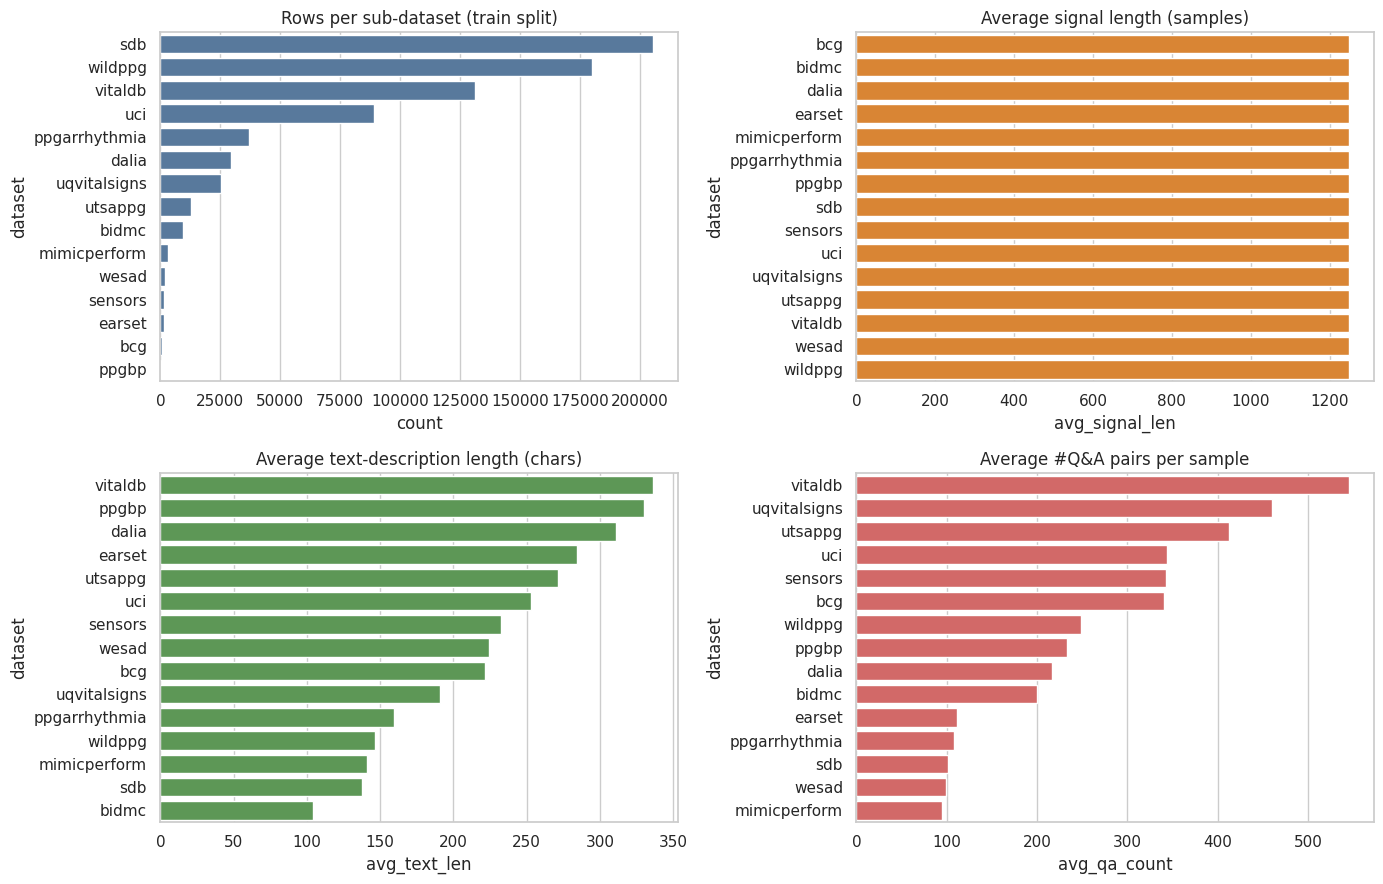

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.barplot(rows_per_ds, x="count", y="dataset", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Rows per sub-dataset (train split)")

sns.barplot(stats_per_ds.sort_values("avg_signal_len", ascending=False),
            x="avg_signal_len", y="dataset", ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Average signal length (samples)")

sns.barplot(stats_per_ds.sort_values("avg_text_len", ascending=False),
            x="avg_text_len", y="dataset", ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Average text-description length (chars)")

sns.barplot(stats_per_ds.sort_values("avg_qa_count", ascending=False),
            x="avg_qa_count", y="dataset", ax=axes[1, 1], color="#E45756")
axes[1, 1].set_title("Average #Q&A pairs per sample")

plt.tight_layout(); plt.show()

### 4.2: Feature importance - F-ratio ranking and box-plots

This section looks at which features separate the different dataset configs the most. The ranking gives a quick sense of which summary statistics carry the most signal, and the box-plots let you see the spread more clearly.

Top-5 most discriminative features:
  dom_freq              F≈6.0676
  kurt                  F≈1.9259
  min                   F≈0.7852
  skew                  F≈0.3757
  mean                  F≈0.3690


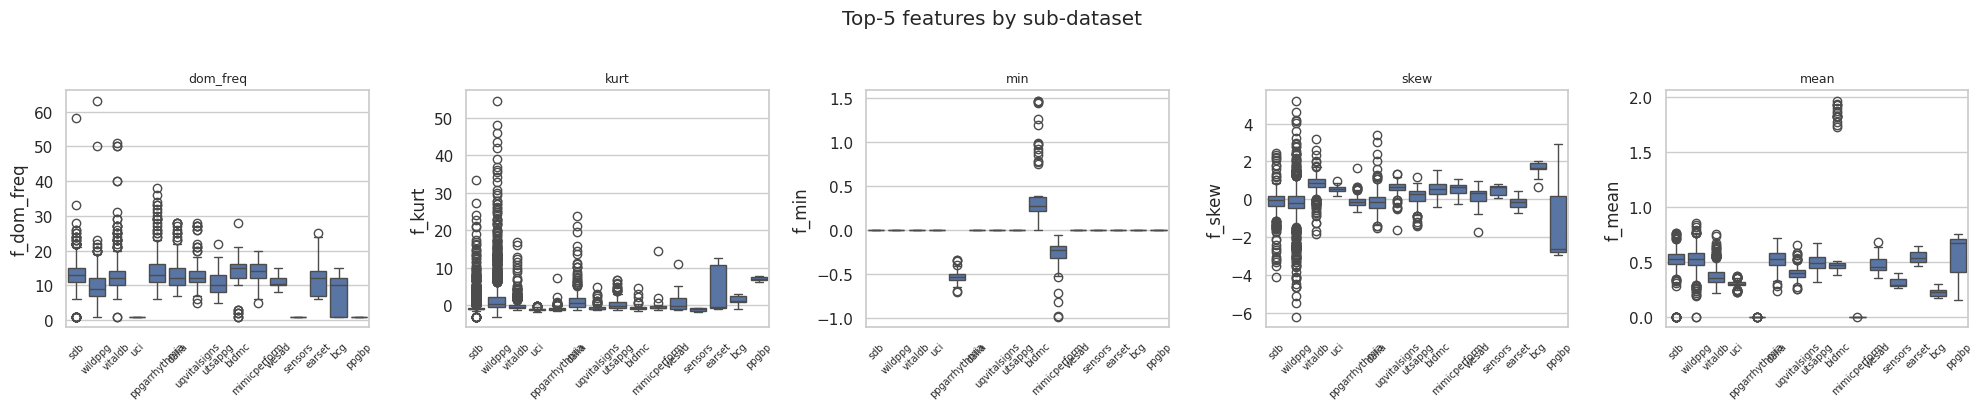

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute per-dataset mean ± std for each feature
agg_exprs_fr = []
for fc in feature_cols:
    agg_exprs_fr.append(F.avg(fc).alias(f"avg_{fc}"))
    agg_exprs_fr.append(F.stddev(fc).alias(f"std_{fc}"))

feat_stats = (
    train_df.groupBy("dataset")
            .agg(*agg_exprs_fr)
            .toPandas()
            .set_index("dataset")
)

feat_names   = [c.replace("f_", "") for c in feature_cols]
avg_cols     = [f"avg_{c}" for c in feature_cols]
std_cols     = [f"std_{c}" for c in feature_cols]
means        = feat_stats[avg_cols].values

# F-ratio proxy: between-dataset variance / pooled within-class std
pooled_std   = feat_stats[std_cols].values.mean(axis=0).clip(1e-9)
between_var  = means.var(axis=0)
f_proxy      = between_var / pooled_std
top5_idx     = f_proxy.argsort()[::-1][:5]
top5_names   = [feat_names[i] for i in top5_idx]

print("Top-5 most discriminative features:")
for i in top5_idx:
    print(f"  {feat_names[i]:<20}  F≈{f_proxy[i]:.4f}")

# Box-plots for top-5 features (1% sample)
fraction    = min(0.01, 1.0)
top5_cols   = [f"f_{n}" for n in top5_names]
sample_pd   = (
    train_df.select(["dataset"] + top5_cols)
            .sample(fraction=fraction, seed=42)
            .toPandas()
)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, fname in zip(axes, top5_names):
    col = f"f_{fname}"
    if col in sample_pd.columns:
        sns.boxplot(data=sample_pd, x="dataset", y=col, ax=ax)
        ax.set_title(fname, fontsize=9)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=7)
fig.suptitle("Top-5 features by sub-dataset", y=1.02)
plt.tight_layout()
plt.show()


### 4.3: Label coverage and class distribution

Here we check how much of each dataset is actually labeled for each task, and what the label balance looks like. This helps explain where a model has enough supervision and where it may be working with thin or skewed data.

In [21]:
# Coverage matrix: one row per config, one column per task, value = fraction of rows labelled.
import pyspark.sql.functions as F

label_cols = [c for c in train_df.columns if c.startswith("lbl_")]

coverage = (
    train_df.groupBy("dataset")
            .agg(*[
                (F.count(F.when(F.col(c).isNotNull(), 1)) / F.count("*")).alias(c)
                for c in label_cols
            ])
            .orderBy("dataset")
            .toPandas()
            .set_index("dataset")
)
coverage.columns = [c.replace("lbl_", "") for c in coverage.columns]
print("Coverage matrix - fraction of train rows in each config that carry each task label:")
print((coverage * 100).round(1).fillna(0).to_string())

Coverage matrix - fraction of train rows in each config that carry each task label:
                  HR     BP  SQI  Stress    SDB  HRV_SDNN  HRV_RMSSD  HRV_pNN50     AF  Arrhythmia  SpO2     RR
dataset                                                                                                        
bcg            100.0  100.0  0.0     0.0    0.0       0.0        0.0        0.0    0.0         0.0   0.0    0.0
bidmc            0.0    0.0  0.0     0.0    0.0       0.0        0.0        0.0    0.0         0.0  78.4  100.0
dalia          100.0    0.0  0.0     0.0    0.0       0.0        0.0        0.0    0.0         0.0   0.0    0.0
earset         100.0    0.0  0.0     0.0    0.0       0.0        0.0        0.0    0.0         0.0   0.0    0.0
mimicperform     0.0    0.0  0.0     0.0    0.0       0.0        0.0        0.0  100.0         0.0   0.0    0.0
ppgarrhythmia    0.0    0.0  0.0     0.0    0.0       0.0        0.0        0.0    0.0       100.0   0.0    0.0
ppgbp          100.0

In [22]:
# Class distribution per task - what unique answer strings appear, and how often?
for task in [c.replace("lbl_", "") for c in label_cols]:
    counts = (
        train_df.filter(F.col(f"lbl_{task}").isNotNull())
                .groupBy(f"lbl_{task}")
                .count()
                .orderBy(F.desc("count"))
                .toPandas()
    )
    if len(counts) == 0:
        print(f"\n[{task}] no labels parsed - check ROUTER_KEYWORDS"); continue
    total = counts["count"].sum()
    print(f"\n[{task}] {total:,} labelled rows, {len(counts)} classes:")
    print(counts.assign(pct=lambda d: (d["count"] / total * 100).round(1)).to_string(index=False))


[HR] 470,920 labelled rows, 3 classes:
     lbl_HR  count  pct
     normal 353736 75.1
bradycardia  59380 12.6
tachycardia  57804 12.3

[BP] 247,816 labelled rows, 5 classes:
             lbl_BP  count  pct
             normal 143128 57.8
hypertension_stage2  47981 19.4
hypertension_stage1  32981 13.3
           elevated  20388  8.2
hypertensive_crisis   3338  1.3

[SQI] no labels parsed - check ROUTER_KEYWORDS

[Stress] 2,104 labelled rows, 4 classes:
lbl_Stress  count  pct
  baseline    932 44.3
    stress    514 24.4
meditation    415 19.7
 amusement    243 11.5

[SDB] 205,618 labelled rows, 4 classes:
            lbl_SDB  count  pct
       normal_ahi<5 131085 63.8
     mild_5<=ahi<15  39271 19.1
moderate_15<=ahi<30  18164  8.8
     severe_ahi>=30  17098  8.3

[HRV_SDNN] 226,828 labelled rows, 3 classes:
lbl_HRV_SDNN  count  pct
         low 178926 78.9
        high  30151 13.3
      normal  17751  7.8

[HRV_RMSSD] 226,828 labelled rows, 3 classes:
lbl_HRV_RMSSD  count  pct
       

### 4.4: Example signals from each dataset

A quick plot of one sample signal from each config helps confirm that the pipeline is seeing the right kind of waveform. It is a practical visual check before moving on to modeling.

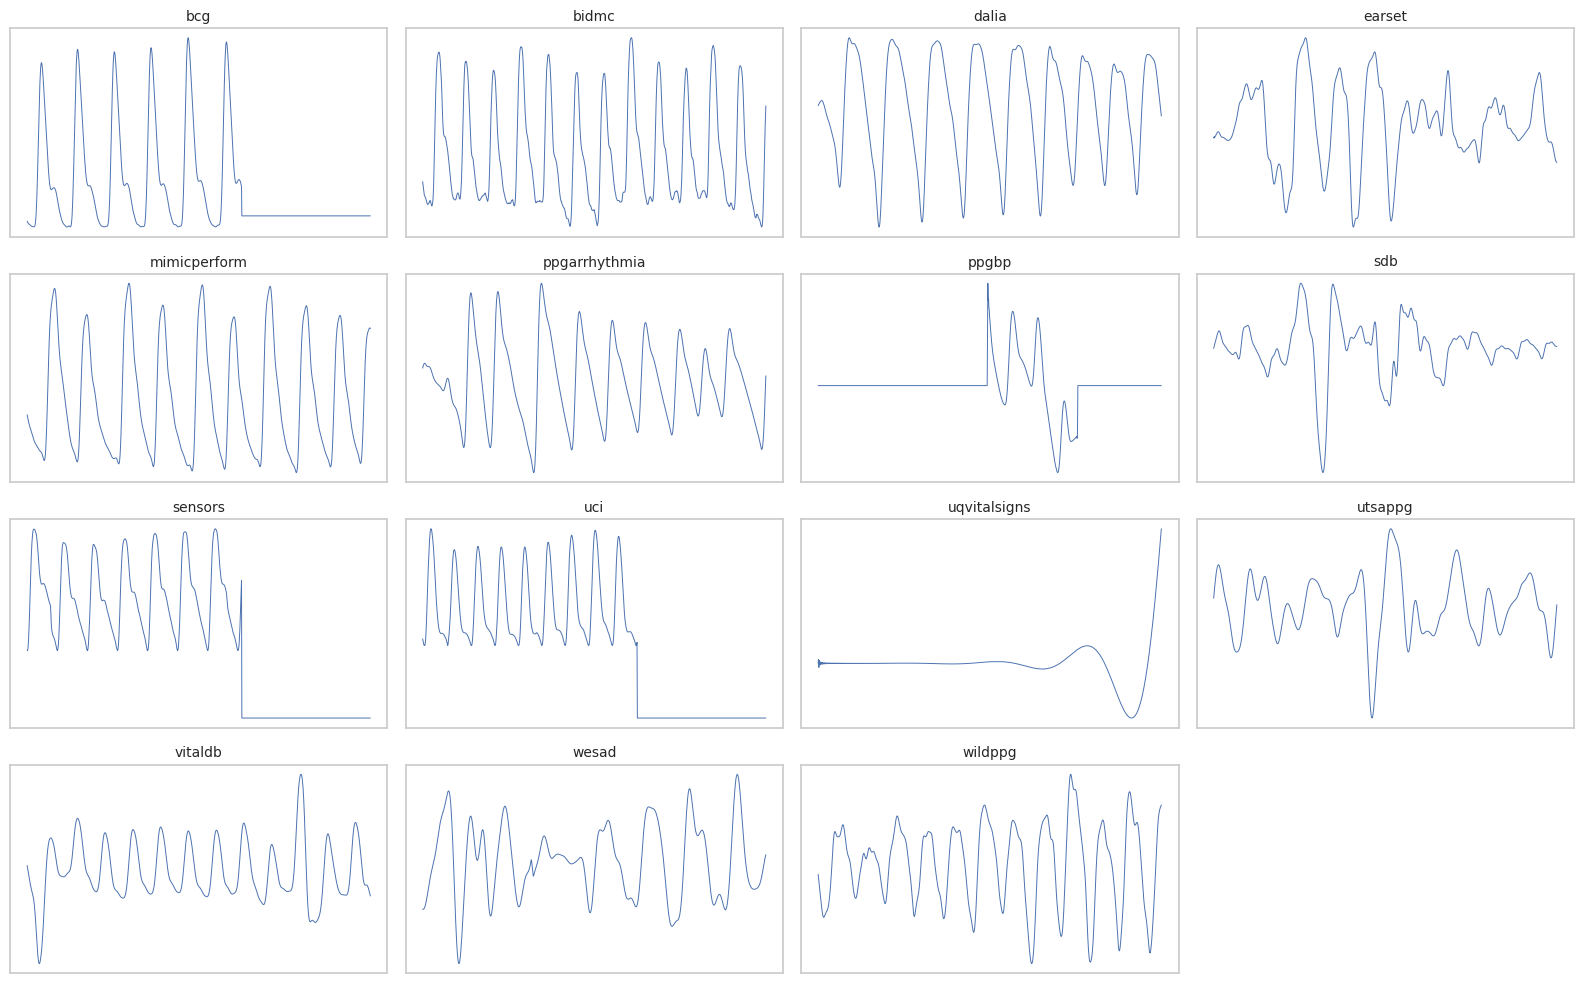

In [23]:
with open(f"{OUT_DIR}/preview_signals.pkl", "rb") as f:
    preview_signals = pickle.load(f)

samples = sorted(preview_signals.items())
n    = len(samples)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 2.5 * rows))
axes = axes.flatten()

for i, (cfg, sig) in enumerate(samples):
    arr = np.asarray(sig, dtype=float)
    axes[i].plot(arr[:1000], linewidth=0.7)
    axes[i].set_title(cfg, fontsize=10)
    axes[i].set_xticks([]); axes[i].set_yticks([])

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout(); plt.show()

## 5: Machine learning pipeline

This part trains a few different models on the labeled features and compares them side by side. The point is to see how far the simple signal summaries can get us before we move to something more complex.

### 5.1: Prepare binary target columns

The raw labels are multi-class text strings, but the models in this notebook are set up to answer a simpler question: normal or abnormal. This step converts the labels into that binary form and prepares the matrices we need later.

In [24]:
import numpy as np
from pyspark.sql import functions as F

# Map text labels to binary 0/1 based on "abnormal" definition per task
ABNORMAL_MAPPING = {
    "HR":         lambda x: x != "normal",
    "BP":         lambda x: x != "normal",
    "Stress":     lambda x: x != "baseline",
    "SDB":        lambda x: not x.startswith("normal"),
    "HRV_SDNN":   lambda x: x != "normal",
    "HRV_RMSSD":  lambda x: x != "normal",
    "HRV_pNN50":  lambda x: x != "normal",
    "AF":         lambda x: x == "af",
    "Arrhythmia": lambda x: x != "sinus_rhythm",
    "RR":         lambda x: x != "normal",
}
ABNORMAL_TASKS = list(ABNORMAL_MAPPING.keys())


def make_binary_label_col(label_col, task):
    """Convert text label to binary 0/1 using task-specific rules."""
    c = F.col(label_col)
    if task in ("HR", "BP", "HRV_SDNN", "HRV_RMSSD", "HRV_pNN50", "RR"):
        return F.when(c == "normal", 0).when(c.isNotNull(), 1).otherwise(None)
    if task == "Stress":
        return F.when(c == "baseline", 0).when(c.isNotNull(), 1).otherwise(None)
    if task == "SDB":
        return F.when(c.startswith("normal"), 0).when(c.isNotNull(), 1).otherwise(None)
    if task == "AF":
        return F.when(c == "af", 1).when(c.isNotNull(), 0).otherwise(None)
    if task == "Arrhythmia":
        return F.when(c == "sinus_rhythm", 0).when(c.isNotNull(), 1).otherwise(None)
    raise ValueError(f"No mapping for task {task}")

def add_binary_label_columns(df):
    """Add y_{task} columns to the DataFrame."""
    for task in ABNORMAL_TASKS:
        df = df.withColumn(f"y_{task}", make_binary_label_col(f"lbl_{task}", task))
    return df

train_df_lbl = add_binary_label_columns(train_df).cache()
val_df_lbl   = add_binary_label_columns(val_df).cache()
test_df_lbl  = add_binary_label_columns(test_df).cache() if test_df is not None else None
_ = train_df_lbl.count()


# Build pandas matrices: Y[i,j] = label for sample i and task j (NaN if unlabeled)
def build_multilabel_targets(df):
    Y = np.full((len(df), len(ABNORMAL_TASKS)), np.nan, dtype=np.float32)
    for j, task in enumerate(ABNORMAL_TASKS):
        col = f"lbl_{task}"
        if col not in df.columns:
            continue
        m = df[col].notna()
        if not m.any():
            continue
        Y[m.values, j] = df.loc[m, col].apply(ABNORMAL_MAPPING[task]).astype(np.float32).values
    return Y, ~np.isnan(Y)

Y_train, M_train = build_multilabel_targets(train_pd)
Y_val,   M_val   = build_multilabel_targets(val_pd)
Y_test,  M_test  = build_multilabel_targets(test_pd) if len(test_pd) else (None, None)


print(f"Spark train_df_lbl cached: {train_df_lbl.count():,} rows")
print(f"Pandas Y_train: {Y_train.shape}  ({M_train.sum():,} observed labels)")

print(f"\n{'task':<12} {'n_train':>9} {'abn%':>8} {'n_val':>8} {'abn%':>8} {'n_test':>8} {'abn%':>8}")
print("-" * 72)

def _stats(Y, M, j):
    if Y is None:
        return (0, float("nan"))
    n = int(M[:, j].sum())
    rate = float(np.nanmean(Y[:, j])) if n else float("nan")
    return (n, rate)

for j, task in enumerate(ABNORMAL_TASKS):
    n_tr, ab_tr = _stats(Y_train, M_train, j)
    n_v,  ab_v  = _stats(Y_val,   M_val,   j)
    n_te, ab_te = _stats(Y_test,  M_test,  j)
    print(f"{task:<12} {n_tr:>9,} {ab_tr*100 if n_tr else 0:>8.1f}% "
          f"{n_v:>8,} {ab_v*100 if n_v else 0:>8.1f}% "
          f"{n_te:>8,} {ab_te*100 if n_te else 0:>8.1f}%")


Spark train_df_lbl cached: 728,621 rows
Pandas Y_train: (728621, 10)  (1,678,571 observed labels)

task           n_train     abn%    n_val     abn%   n_test     abn%
------------------------------------------------------------------------
HR             470,920     24.9%   51,859     25.0%   90,459     16.6%
BP             247,816     42.2%   30,742     41.4%   34,549     39.6%
Stress           2,104     55.7%      297     60.3%      597     60.5%
SDB            205,618     36.2%   23,525     40.2%   29,754     39.0%
HRV_SDNN       226,828     92.2%   23,677     88.3%   41,945     93.2%
HRV_RMSSD      226,828     82.1%   23,677     80.8%   41,945     86.9%
HRV_pNN50      226,828     85.8%   23,677     83.0%   41,945     89.1%
AF               3,239     55.6%      240     50.0%      717     50.1%
Arrhythmia      36,820     66.8%    4,764     71.1%    5,243     80.7%
RR              31,570     45.2%    4,181     53.5%    9,556     49.3%


### 5.1b: Inverse-frequency class weights

Some tasks are heavily imbalanced, with many normal examples and far fewer abnormal ones. These weights give the rare class more influence during training so the model does not just learn the majority answer.

In [25]:
import pyspark.sql.functions as F

# Compute inverse-frequency weights per task
task_weight_maps = {}
for task in ABNORMAL_TASKS:
    ycol = f"y_{task}"
    counts_rows = (
        train_df_lbl
        .filter(F.col(ycol).isNotNull())
        .groupBy(ycol)
        .count()
        .collect()
    )
    if not counts_rows:
        continue
    total = sum(r["count"] for r in counts_rows)
    n_cls = 2
    task_weight_maps[task] = {
        int(r[ycol]): round(total / (n_cls * r["count"]), 4)
        for r in counts_rows
    }

print(f"{'task':<14}  {'w(normal=0)':>12}  {'w(abnormal=1)':>14}  {'ratio':>8}")
print("-" * 55)
for task, wmap in task_weight_maps.items():
    w0 = wmap.get(0, float("nan"))
    w1 = wmap.get(1, float("nan"))
    ratio = w1 / w0 if w0 else float("nan")
    print(f"{task:<14}  {w0:>12.4f}  {w1:>14.4f}  {ratio:>8.2f}×")

# Add weight columns to train_df_lbl
def _add_weight_col(df, task, wmap):
    ycol  = f"y_{task}"
    wcol  = f"wt_{task}"
    expr  = F.lit(1.0)
    for cls_int, w in wmap.items():
        expr = F.when(F.col(ycol) == cls_int, w).otherwise(expr)
    return df.withColumn(wcol, expr)

for task, wmap in task_weight_maps.items():
    train_df_lbl = _add_weight_col(train_df_lbl, task, wmap)

train_df_lbl = train_df_lbl.cache()
_ = train_df_lbl.count()
print(f"\nAdded {len(task_weight_maps)} weight columns. Re-cached.")


task             w(normal=0)   w(abnormal=1)     ratio
-------------------------------------------------------
HR                    0.6656          2.0093      3.02×
BP                    0.8657          1.1836      1.37×
Stress                1.1288          0.8976      0.80×
SDB                   0.7843          1.3794      1.76×
HRV_SDNN              6.3892          0.5425      0.08×
HRV_RMSSD             2.7979          0.6088      0.22×
HRV_pNN50             3.5139          0.5829      0.17×
AF                    1.1254          0.8997      0.80×
Arrhythmia            1.5070          0.7483      0.50×
RR                    0.9132          1.1051      1.21×

Added 10 weight columns. Re-cached.


### 5.2: Spark Random Forest - subset training

This version trains one random forest per task, using only the rows that already have a label for that task. It is a straightforward baseline and a good way to see how much signal there is in the features alone.

In [26]:
from pyspark.ml.feature      import VectorAssembler, StandardScaler as SparkScaler
from pyspark.ml.classification import RandomForestClassifier as SparkRF, MultilayerPerceptronClassifier
from pyspark.ml.evaluation    import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.sql.types import DoubleType
import time

SP_NUM_TREES    = 50
SP_MAX_DEPTH    = 15
SP_MAX_BINS     = 32
SP_MLP_LAYERS   = [9, 16, 8, 2]
SP_MLP_MAX_ITER = 50
SP_MLP_STEP     = 0.05

_assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
_scaler    = SparkScaler(inputCol="raw_features", outputCol="features",
                          withMean=True, withStd=True)

def _spark_per_task_train(task, df_train, df_val, df_test, model_kind="rf",
                          use_weights=False, sample_cap=None, keep_model=False):
    """Train one binary classifier per task."""
    ycol = f"y_{task}"

    if use_weights:
        wcol = f"wt_{task}"
        if wcol in df_train.columns:
            df_tr = df_train.withColumn(
                ycol, F.when(F.col(ycol).isNotNull(), F.col(ycol)).otherwise(0))
        else:
            wcol = ycol + "_w"
            df_tr = (df_train
                     .withColumn(wcol, F.when(F.col(ycol).isNotNull(), 1.0).otherwise(0.0))
                     .withColumn(ycol, F.when(F.col(ycol).isNotNull(), F.col(ycol)).otherwise(0)))
        weight_col = wcol
    else:
        df_tr = df_train.filter(F.col(ycol).isNotNull())
        weight_col = None

    if sample_cap is not None:
        n_have = df_tr.count()
        if n_have > sample_cap:
            df_tr = df_tr.sample(False, sample_cap / n_have, seed=42)

    n_train = df_tr.count()
    classes = [r[0] for r in df_tr.select(ycol).distinct().collect()]
    if n_train < 200 or len([c for c in classes if c is not None]) < 2:
        return None

    # MLlib requires DoubleType labels
    df_tr = df_tr.withColumn(ycol, F.col(ycol).cast(DoubleType()))

    if model_kind == "rf":
        clf = SparkRF(featuresCol="features", labelCol=ycol,
                       numTrees=SP_NUM_TREES, maxDepth=SP_MAX_DEPTH,
                       maxBins=SP_MAX_BINS, seed=42,
                       **({"weightCol": weight_col} if weight_col else {}))
    elif model_kind == "mlp":
        clf = MultilayerPerceptronClassifier(featuresCol="features", labelCol=ycol,
                                              layers=SP_MLP_LAYERS,
                                              maxIter=SP_MLP_MAX_ITER,
                                              stepSize=SP_MLP_STEP, seed=42)
    else:
        raise ValueError(model_kind)

    pipe  = SparkPipeline(stages=[_assembler, _scaler, clf])
    t0    = time.perf_counter()
    fitted = pipe.fit(df_tr)
    train_secs = time.perf_counter() - t0

    def _eval(df):
        if df is None:
            return None
        d = df.filter(F.col(ycol).isNotNull())
        if d.rdd.isEmpty():
            return None
        pred = fitted.transform(d)
        acc = MulticlassClassificationEvaluator(labelCol=ycol, predictionCol="prediction",
                                                 metricName="accuracy").evaluate(pred)
        f1  = MulticlassClassificationEvaluator(labelCol=ycol, predictionCol="prediction",
                                                 metricName="f1").evaluate(pred)
        return {"n": d.count(), "acc": acc, "f1_macro": f1}

    out = {"task": task, "n_train": n_train, "train_secs": train_secs,
           "val": _eval(df_val), "test": _eval(df_test)}
    if keep_model:
        out["pipeline"] = fitted
    return out


# Subset training: one RF per task on labeled rows only
results_sp_rf_subset = {}
print(f"  {'task':<12}  {'n_train':>8}  {'val_acc':>8}  {'val_f1':>7}  {'test_acc':>9}  {'test_f1':>8}  {'secs':>6}")
print("  " + "-" * 64)
for task in ABNORMAL_TASKS:
    r = _spark_per_task_train(task, train_df_lbl, val_df_lbl, test_df_lbl,
                                model_kind="rf", use_weights=False, sample_cap=100_000)
    if r is None:
        print(f"  {task:<12}  [skip - insufficient data]")
        continue
    results_sp_rf_subset[task] = r
    va = r["val"] or {}; te = r["test"] or {}
    print(f"  {task:<12}  {r['n_train']:>8,}  "
          f"{va.get('acc', float('nan')):>8.3f}  {va.get('f1_macro', float('nan')):>7.3f}  "
          f"{te.get('acc', float('nan')):>9.3f}  {te.get('f1_macro', float('nan')):>8.3f}  "
          f"{r['train_secs']:>6.1f}")
print(f"\nTrained {len(results_sp_rf_subset)} RFs (subset training).")


  task           n_train   val_acc   val_f1   test_acc   test_f1    secs
  ----------------------------------------------------------------
  HR             100,222     0.851    0.838      0.875     0.859   117.1
  BP             100,254     0.654    0.648      0.612     0.604    95.5
  Stress           2,104     0.512    0.473      0.615     0.613     9.7
  SDB            100,287     0.526    0.510      0.597     0.574   110.0
  HRV_SDNN       100,094     0.884    0.831      0.932     0.899    95.1
  HRV_RMSSD      100,094     0.801    0.727      0.868     0.817   108.6
  HRV_pNN50      100,094     0.830    0.753      0.891     0.839    98.5
  AF               3,239     0.500    0.333      0.409     0.328     7.6
  Arrhythmia      36,820     0.903    0.904      0.930     0.931    49.1
  RR              31,570     0.640    0.637      0.512     0.508    39.8

Trained 10 RFs (subset training).


### 5.3: Spark Random Forest - whole-dataset training with weights

This version uses the full dataset instead of only the labeled rows. Missing labels are effectively ignored by giving them zero weight, which makes the setup more convenient for comparison while keeping the training logic similar.

In [27]:
# Whole-dataset Spark RF - also keeps the fitted pipelines so demo can use them.
results_sp_rf_whole = {}
print(f"  {'task':<12}  {'n_train':>9}  {'val_acc':>8}  {'val_f1':>7}  {'test_acc':>9}  {'test_f1':>8}  {'secs':>6}")
print("  " + "-" * 64)
for task in ABNORMAL_TASKS:
    r = _spark_per_task_train(task, train_df_lbl, val_df_lbl, test_df_lbl,
                                model_kind="rf", use_weights=True, sample_cap=None,
                                keep_model=True)
    if r is None:
        print(f"  {task:<12}  [skip - insufficient data]"); continue
    results_sp_rf_whole[task] = r
    va = r["val"] or {}; te = r["test"] or {}
    print(f"  {task:<12}  {r['n_train']:>9,}  "
          f"{va.get('acc', float('nan')):>8.3f}  {va.get('f1_macro', float('nan')):>7.3f}  "
          f"{te.get('acc', float('nan')):>9.3f}  {te.get('f1_macro', float('nan')):>8.3f}  "
          f"{r['train_secs']:>6.1f}")
print(f"\nTrained {len(results_sp_rf_whole)} Spark RFs (whole-dataset with weightCol).")

  task            n_train   val_acc   val_f1   test_acc   test_f1    secs
  ----------------------------------------------------------------
  HR              728,621     0.786    0.793      0.813     0.820   380.1
  BP              728,621     0.645    0.646      0.587     0.587   381.8
  Stress          728,621     0.401    0.233      0.395     0.224   276.5
  SDB             728,621     0.462    0.441      0.615     0.582   385.9
  HRV_SDNN        728,621     0.556    0.629      0.324     0.419   384.3
  HRV_RMSSD       728,621     0.512    0.554      0.325     0.369   386.0
  HRV_pNN50       728,621     0.527    0.578      0.322     0.382   351.6
  AF              728,621     0.988    0.987      0.590     0.590   114.9
  Arrhythmia      728,621     0.873    0.877      0.908     0.911   123.8
  RR              728,621     0.452    0.290      0.513     0.369   297.0

Trained 10 Spark RFs (whole-dataset with weightCol).


### 5.4: Spark MLP - multi-layer perceptron per task

This is the neural-network version inside Spark. It is still trained one task at a time, but the model itself can learn a slightly richer decision boundary than the random forest.

In [28]:
results_sp_mlp = {}
print(f"  {'task':<12}  {'n_train':>8}  {'val_acc':>8}  {'val_f1':>7}  {'test_acc':>9}  {'test_f1':>8}  {'secs':>6}")
print("  " + "-" * 64)
for task in ABNORMAL_TASKS:
    r = _spark_per_task_train(task, train_df_lbl, val_df_lbl, test_df_lbl,
                                model_kind="mlp", use_weights=False, sample_cap=50_000)
    if r is None:
        print(f"  {task:<12}  [skip - insufficient data]"); continue
    results_sp_mlp[task] = r
    va = r["val"] or {}; te = r["test"] or {}
    print(f"  {task:<12}  {r['n_train']:>8,}  "
          f"{va.get('acc', float('nan')):>8.3f}  {va.get('f1_macro', float('nan')):>7.3f}  "
          f"{te.get('acc', float('nan')):>9.3f}  {te.get('f1_macro', float('nan')):>8.3f}  "
          f"{r['train_secs']:>6.1f}")
print(f"\nTrained {len(results_sp_mlp)} Spark MLPs (per-task binary).")

  task           n_train   val_acc   val_f1   test_acc   test_f1    secs
  ----------------------------------------------------------------
  HR              49,933     0.826    0.807      0.859     0.842    16.1
  BP              50,228     0.640    0.640      0.589     0.589     8.2
  Stress           2,104     0.522    0.431      0.561     0.557     3.0
  SDB             50,173     0.524    0.498      0.585     0.565     9.9
  HRV_SDNN        50,159     0.883    0.828      0.932     0.899     9.4
  HRV_RMSSD       50,159     0.808    0.722      0.868     0.809     8.2
  HRV_pNN50       50,159     0.830    0.753      0.891     0.839     8.6
  AF               3,239     0.487    0.328      0.462     0.436     3.9
  Arrhythmia      36,820     0.877    0.880      0.916     0.917     6.2
  RR              31,570     0.468    0.396      0.524     0.524     5.9

Trained 10 Spark MLPs (per-task binary).


### 5.5: PyTorch multi-task NN (bonus baseline)

This model shares one feature trunk across all tasks and gives each task its own output head. It is useful as a stronger baseline when you want to see whether shared learning helps across related labels.

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F_torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Standardize features
_pt_scaler = StandardScaler().fit(train_pd[feature_cols].values)
X_train_full = _pt_scaler.transform(train_pd[feature_cols].values).astype("float32")
X_val_full   = _pt_scaler.transform(val_pd[feature_cols].values).astype("float32")
X_test_full  = _pt_scaler.transform(test_pd[feature_cols].values).astype("float32") if len(test_pd) else None

def _to_tensors(X, Y, M):
    if X is None:
        return (None, None, None)
    Yc = np.where(np.isnan(Y), 0.0, Y).astype("float32")
    return (torch.from_numpy(X), torch.from_numpy(Yc), torch.from_numpy(M.astype("float32")))

X_tr_t, Y_tr_t, M_tr_t = _to_tensors(X_train_full, Y_train, M_train)
X_v_t,  Y_v_t,  M_v_t  = _to_tensors(X_val_full,   Y_val,   M_val)
X_te_t, Y_te_t, M_te_t = _to_tensors(X_test_full,  Y_test,  M_test) if X_test_full is not None else (None, None, None)

n_tasks  = len(ABNORMAL_TASKS)
n_inputs = len(feature_cols)
print(f"Training: {X_tr_t.shape[0]:,} rows × {n_inputs} features → {n_tasks} binary heads")


class MultiTaskMLP(nn.Module):
    def __init__(self, in_dim, n_tasks, hidden=64):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.2),
        )
        self.head = nn.Linear(hidden, n_tasks)
    def forward(self, x):
        return self.head(self.trunk(x))


torch.manual_seed(42)
model = MultiTaskMLP(n_inputs, n_tasks, hidden=64).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Inverse-frequency class weights
pos_rate   = np.array([np.nanmean(Y_train[:, j]) if M_train[:, j].any() else 0.5 for j in range(n_tasks)], dtype="float32")
pos_weight = torch.from_numpy(np.where(pos_rate > 0, (1 - pos_rate) / np.clip(pos_rate, 1e-3, 1.0), 1.0).astype("float32")).to(device)

def masked_bce(logits, targets, mask):
    """Binary cross-entropy with task masking."""
    loss_per = F_torch.binary_cross_entropy_with_logits(logits, targets, reduction="none", pos_weight=pos_weight)
    return (loss_per * mask).sum() / mask.sum().clamp(min=1.0)

BATCH_SIZE, EPOCHS, PATIENCE = 1024, 30, 5
train_loader = DataLoader(TensorDataset(X_tr_t, Y_tr_t, M_tr_t),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
X_v_d, Y_v_d, M_v_d = X_v_t.to(device), Y_v_t.to(device), M_v_t.to(device)

def _val_macro_f1():
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_v_d)) >= 0.5).cpu().numpy().astype(int)
    f1s = []
    for j in range(n_tasks):
        m = M_val[:, j]
        if m.sum() < 10:
            continue
        y = Y_val[m.astype(bool), j].astype(int)
        if len(set(y)) < 2:
            continue
        f1s.append(f1_score(y, preds[m.astype(bool), j], average="macro", zero_division=0))
    return float(np.mean(f1s)) if f1s else float("nan")

history = []
best_f1, best_state, since_best = -1.0, None, 0
for epoch in range(1, EPOCHS + 1):
    model.train()
    tl, nb_ = 0.0, 0
    for xb, yb, mb in train_loader:
        xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
        opt.zero_grad()
        loss = masked_bce(model(xb), yb, mb)
        loss.backward()
        opt.step()
        tl += loss.item()
        nb_ += 1
    val_f1 = _val_macro_f1()
    history.append({"epoch": epoch, "train_loss": tl/nb_, "val_f1_macro": val_f1})
    print(f"  epoch {epoch:>2d}  train_loss={tl/nb_:.4f}  val_f1={val_f1:.3f}")
    if val_f1 > best_f1:
        best_f1, best_state, since_best = val_f1, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
    else:
        since_best += 1
        if since_best >= PATIENCE:
            print(f"  early stop at epoch {epoch}")
            break

if best_state is not None:
    model.load_state_dict(best_state)
print(f"\nBest val macro-F1: {best_f1:.3f}")


Using device: cpu
Training: 728,621 rows × 9 features → 10 binary heads
  epoch  1  train_loss=0.5450  val_f1=0.554
  epoch  2  train_loss=0.5077  val_f1=0.563
  epoch  3  train_loss=0.4996  val_f1=0.565
  epoch  4  train_loss=0.4960  val_f1=0.553
  epoch  5  train_loss=0.4939  val_f1=0.559
  epoch  6  train_loss=0.4927  val_f1=0.559
  epoch  7  train_loss=0.4916  val_f1=0.556
  epoch  8  train_loss=0.4909  val_f1=0.558
  early stop at epoch 8

Best val macro-F1: 0.565


  task           val_acc   val_f1   test_acc   test_f1
  --------------------------------------------------------
  HR               0.763    0.719      0.785     0.681
  BP               0.631    0.630      0.564     0.562
  Stress           0.286    0.266      0.570     0.569
  SDB              0.487    0.482      0.535     0.519
  HRV_SDNN         0.659    0.566      0.390     0.339
  HRV_RMSSD        0.610    0.557      0.417     0.389
  HRV_pNN50        0.630    0.565      0.382     0.355
  AF               0.467    0.318      0.573     0.572
  Arrhythmia       0.779    0.764      0.861     0.805
  RR               0.787    0.785      0.485     0.465


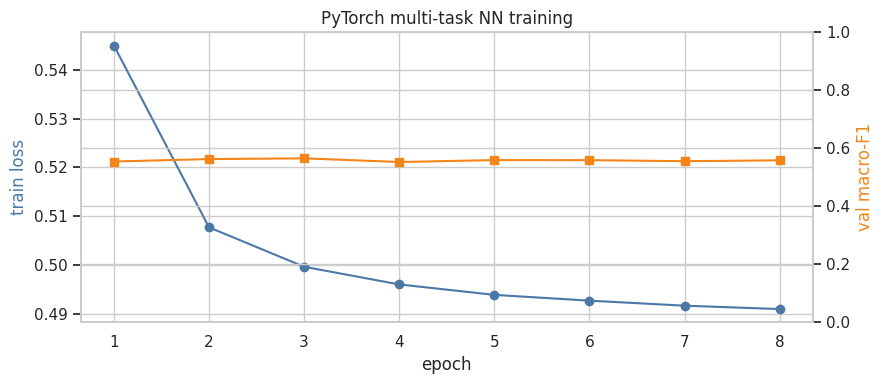

In [30]:
def _nn_per_task(X_t, Y_np, M_np):
    if X_t is None: return None
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_t.to(device))) >= 0.5).cpu().numpy().astype(int)
    out = {}
    for j, task in enumerate(ABNORMAL_TASKS):
        m = M_np[:, j].astype(bool)
        if m.sum() < 10:
            out[task] = None; continue
        y = Y_np[m, j].astype(int)
        if len(set(y)) < 2:
            out[task] = {"n": int(m.sum()), "acc": accuracy_score(y, preds[m, j]),
                         "f1_macro": float("nan"), "y_true": y, "y_pred": preds[m, j]}
            continue
        out[task] = {"n":        int(m.sum()),
                     "acc":      accuracy_score(y, preds[m, j]),
                     "f1_macro": f1_score(y, preds[m, j], average="macro", zero_division=0),
                     "y_true":   y, "y_pred": preds[m, j]}
    return out

per_task_val  = _nn_per_task(X_v_t,  Y_val,  M_val)
per_task_test = _nn_per_task(X_te_t, Y_test, M_test) if X_te_t is not None else None

results_nn = {}
print(f"  {'task':<12}  {'val_acc':>8}  {'val_f1':>7}  {'test_acc':>9}  {'test_f1':>8}")
print("  " + "-" * 56)
for task in ABNORMAL_TASKS:
    va = (per_task_val  or {}).get(task) or {}
    te = (per_task_test or {}).get(task) or {}
    results_nn[task] = {"val": va or None, "test": te or None}
    print(f"  {task:<12}  "
          f"{va.get('acc',  float('nan')):>8.3f}  {va.get('f1_macro', float('nan')):>7.3f}  "
          f"{te.get('acc',  float('nan')):>9.3f}  {te.get('f1_macro', float('nan')):>8.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
hist_df = pd.DataFrame(history)
ax2 = ax.twinx()
ax.plot(hist_df["epoch"],  hist_df["train_loss"],   marker="o", color="#4C78A8", label="train loss")
ax2.plot(hist_df["epoch"], hist_df["val_f1_macro"], marker="s", color="#F58518", label="val macro-F1")
ax.set_xlabel("epoch"); ax.set_ylabel("train loss", color="#4C78A8")
ax2.set_ylabel("val macro-F1", color="#F58518"); ax2.set_ylim(0, 1)
ax.set_title("PyTorch multi-task NN training")
plt.tight_layout(); plt.show()

### 5.6: Model comparison and baseline

Now that the models have been trained, this section lines them up side by side on the test set. It also includes a simple majority-class baseline so you can see whether the models are doing anything better than a trivial guess.

Models available: ['Spark RF - subset', 'Spark RF - whole', 'Spark MLP', 'PyTorch NN']


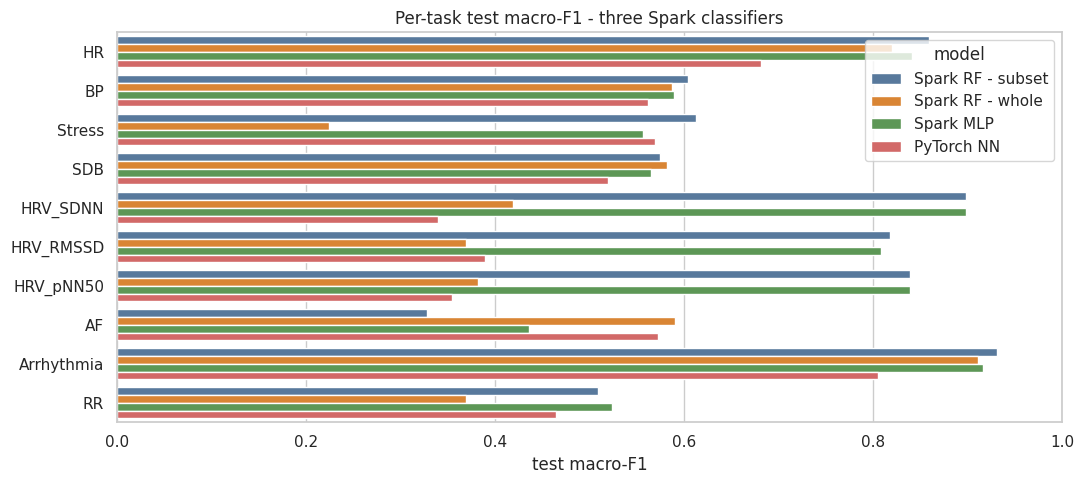


Test macro-F1 table:
model       PyTorch NN  Spark MLP  Spark RF - subset  Spark RF - whole
task                                                                  
AF               0.572      0.436              0.328             0.590
Arrhythmia       0.805      0.917              0.931             0.911
BP               0.562      0.589              0.604             0.587
HR               0.681      0.842              0.859             0.820
HRV_RMSSD        0.389      0.809              0.817             0.369
HRV_SDNN         0.339      0.899              0.899             0.419
HRV_pNN50        0.355      0.839              0.839             0.382
RR               0.465      0.524              0.508             0.369
SDB              0.519      0.565              0.574             0.582
Stress           0.569      0.557              0.613             0.224


In [31]:
rows = []
sources = [
    ("Spark RF - subset",   globals().get("results_sp_rf_subset")),
    ("Spark RF - whole",    globals().get("results_sp_rf_whole")),
    ("Spark MLP",            globals().get("results_sp_mlp")),
    ("PyTorch NN",           globals().get("results_nn")),
]
present = [(n, d) for n, d in sources if d is not None]
print("Models available:", [n for n, _ in present])

for task in ABNORMAL_TASKS:
    for name, d in present:
        r = d.get(task)
        if not r: continue
        te = r.get("test")
        if not te: continue
        f1 = te.get("f1_macro")
        if f1 is None or (isinstance(f1, float) and np.isnan(f1)): continue
        rows.append({"task": task, "model": name, "test_f1": f1})

if not rows:
    print("No results yet - run the training cells above to populate the comparison.")
else:
    comp = pd.DataFrame(rows)
    palette = {"Spark RF - subset": "#4C78A8",
               "Spark RF - whole":  "#F58518",
               "Spark MLP":          "#54A24B",
               "PyTorch NN":         "#E45756"}
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(comp, y="task", x="test_f1", hue="model", ax=ax,
                palette=[palette[m] for m in comp["model"].unique()])
    ax.set_xlim(0, 1); ax.set_title("Per-task test macro-F1 - three Spark classifiers")
    ax.set_xlabel("test macro-F1"); ax.set_ylabel("")
    plt.tight_layout(); plt.show()

    pivot = comp.pivot(index="task", columns="model", values="test_f1")
    print("\nTest macro-F1 table:")
    print(pivot.round(3).fillna("--").to_string())

Majority-class baseline vs best Spark model (test macro-F1):
            majority_class  majority_pct  baseline_acc  baseline_f1  best_model_f1   lift
task                                                                                     
HR                       0         0.751         0.834        0.429          0.859  0.430
BP                       0         0.578         0.604        0.366          0.604  0.238
Stress                   1         0.557         0.605        0.358          0.613  0.255
SDB                      0         0.638         0.610        0.389          0.582  0.193
HRV_SDNN                 1         0.922         0.932        0.480          0.899  0.419
HRV_RMSSD                1         0.821         0.869        0.451          0.817  0.367
HRV_pNN50                1         0.858         0.891        0.462          0.839  0.378
AF                       1         0.556         0.501        0.357          0.590  0.233
Arrhythmia               1         0.66

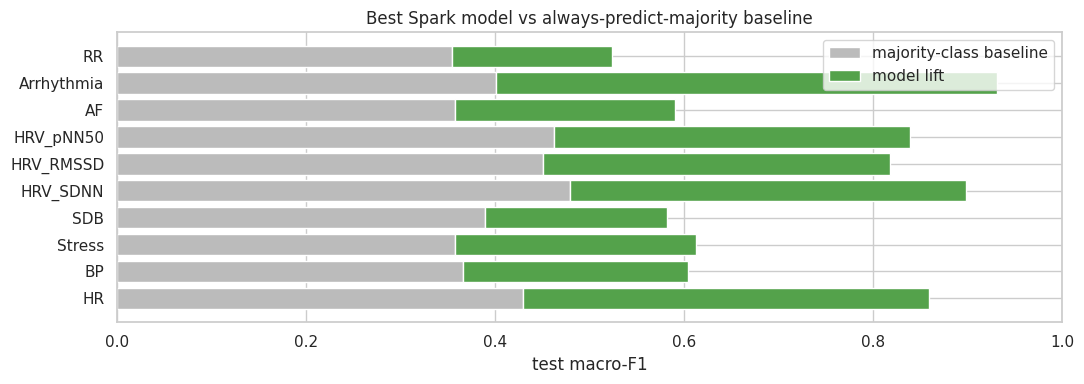

In [32]:
# Majority-class baseline for comparison.
baseline_rows = []
for task in ABNORMAL_TASKS:
    ycol = f"y_{task}"
    tr = train_df_lbl.filter(F.col(ycol).isNotNull())
    te = test_df_lbl.filter(F.col(ycol).isNotNull()) if test_df_lbl is not None else None
    if te is None or te.rdd.isEmpty(): continue

    # Find the majority class on the training set.
    maj_row = (tr.groupBy(ycol).count().orderBy(F.desc("count")).first())
    if maj_row is None: continue
    maj_class = int(maj_row[ycol])

    # Score a constant predictor on the test split.
    test_with_pred = te.withColumn("prediction", F.lit(float(maj_class)))
    acc = MulticlassClassificationEvaluator(
        labelCol=ycol, predictionCol="prediction", metricName="accuracy"
    ).evaluate(test_with_pred)

    # Keep macro-F1 explicit so it stays comparable with the model scores.
    n_tr_total = tr.count()
    maj_frac   = maj_row["count"] / n_tr_total
    f1_maj     = (2 * maj_frac * 1.0) / (maj_frac + 1.0)
    baseline_macro_f1 = f1_maj / 2.0

    baseline_rows.append({
        "task":           task,
        "majority_class":  maj_class,
        "majority_pct":    maj_frac,
        "baseline_acc":   acc,
        "baseline_f1":    baseline_macro_f1,
    })

baseline_df = pd.DataFrame(baseline_rows).set_index("task")

# Compare against the best model's test F1 per task.
def _best_test_f1(task):
    best = None
    for d in [results_sp_rf_subset, results_sp_rf_whole, results_sp_mlp]:
        r = (d or {}).get(task)
        if r and r.get("test") and r["test"].get("f1_macro") is not None:
            f1 = r["test"]["f1_macro"]
            if best is None or f1 > best:
                best = f1
    return best

baseline_df["best_model_f1"] = [_best_test_f1(t) for t in baseline_df.index]
baseline_df["lift"]          = baseline_df["best_model_f1"] - baseline_df["baseline_f1"]

print("Majority-class baseline vs best Spark model (test macro-F1):")
print(baseline_df.round(3).to_string())

# Plot baseline against the best model.
fig, ax = plt.subplots(figsize=(11, 4))
xs = range(len(baseline_df))
ax.barh(xs, baseline_df["baseline_f1"], color="#bbbbbb", label="majority-class baseline")
ax.barh(xs, baseline_df["best_model_f1"] - baseline_df["baseline_f1"],
        left=baseline_df["baseline_f1"], color="#54A24B", label="model lift")
ax.set_yticks(list(xs)); ax.set_yticklabels(baseline_df.index)
ax.set_xlabel("test macro-F1"); ax.set_xlim(0, 1)
ax.set_title("Best Spark model vs always-predict-majority baseline")
ax.legend(); plt.tight_layout(); plt.show()

### 5.7: Run clinical predictions on test signals

This last section applies the trained network to real test examples and prints the predictions in a readable way. It is the closest thing in the notebook to a worked example of how the model behaves on actual signals.

In [33]:
TASK_QUESTIONS = {
    "HR":         "Is the heart rate abnormal (brady- or tachycardia)?",
    "BP":         "Is the blood pressure abnormal (elevated / hypertensive)?",
    "Stress":     "Is the subject in a non-baseline emotional state?",
    "SDB":        "Does the patient have any sleep-disordered breathing (apnea)?",
    "HRV_SDNN":   "Is the HRV (SDNN) abnormal?",
    "HRV_RMSSD":  "Is the HRV (RMSSD) abnormal?",
    "HRV_pNN50":  "Is the HRV (pNN50) abnormal?",
    "AF":         "Does this signal show atrial fibrillation?",
    "Arrhythmia": "Does this signal show any arrhythmia (vs. sinus rhythm)?",
    "RR":         "Is the respiratory rate abnormal (brady- or tachypnea)?",
}


def predict_clinical(features_row, threshold=0.5):
    """Get predictions for all tasks from one signal's features."""
    x = torch.from_numpy(np.asarray(features_row, dtype="float32").reshape(1, -1)).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(x)).cpu().numpy().ravel()
    return {task: (bool(probs[j] >= threshold), float(probs[j]))
            for j, task in enumerate(ABNORMAL_TASKS)}


def explain_row(pos_idx, df=test_pd, X_scaled=X_test_full):
    """Show model predictions and compare to ground truth for one test sample."""
    pred = predict_clinical(X_scaled[pos_idx])
    print(f"\n=== Row {pos_idx}  (dataset={df.iloc[pos_idx]['dataset']}) ===")
    print(f"{'question':<60} {'pred':>8} {'p(abn)':>8}  ground truth")
    print("-" * 100)
    for task in ABNORMAL_TASKS:
        yn, p = pred[task]
        col   = f"lbl_{task}"
        truth_raw = df.iloc[pos_idx].get(col)
        if pd.isna(truth_raw):
            truth_str = "--"
            mark = " "
        else:
            truth_is_abn = ABNORMAL_MAPPING[task](truth_raw)
            truth_str = f"{'Yes' if truth_is_abn else 'No':<3}  ({truth_raw})"
            mark = "✓" if truth_is_abn == yn else "✗"
        print(f"{TASK_QUESTIONS[task]:<60} {'Yes' if yn else 'No':>8} {p:>8.2f}  {mark} {truth_str}")


# Show predictions on a few test examples
sample_rows = []
for cfg in ["ppgarrhythmia", "sdb", "wesad", "uci", "vitaldb"]:
    cand = test_pd[test_pd["dataset"] == cfg]
    if len(cand) > 0:
        sample_rows.append(test_pd.index.get_loc(cand.index[0]))
sample_rows = sample_rows[:4]

for pos_idx in sample_rows:
    explain_row(pos_idx)



=== Row 7863  (dataset=ppgarrhythmia) ===
question                                                         pred   p(abn)  ground truth
----------------------------------------------------------------------------------------------------
Is the heart rate abnormal (brady- or tachycardia)?               Yes     0.69    --
Is the blood pressure abnormal (elevated / hypertensive)?         Yes     0.59    --
Is the subject in a non-baseline emotional state?                 Yes     0.56    --
Does the patient have any sleep-disordered breathing (apnea)?      Yes     0.70    --
Is the HRV (SDNN) abnormal?                                       Yes     0.51    --
Is the HRV (RMSSD) abnormal?                                      Yes     0.59    --
Is the HRV (pNN50) abnormal?                                       No     0.50    --
Does this signal show atrial fibrillation?                        Yes     0.67    --
Does this signal show any arrhythmia (vs. sinus rhythm)?          Yes     0.89  ✓ 